# 🌍 SeismoSense Intelligence System
### **Version 4.2 - Ultimate Metric Stability**

---

## [1] Environment Setup & Dependencies

In [32]:
import os, sys, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="viridis")
print("[Cell 1] Core logic initialized.")

[Cell 1] Core logic initialized.


## [2] Data Ingress & Cleansing

In [33]:
DATA_FILE = 'EarthquakeData (2015-2024).csv'

if os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    df = df.rename(columns={'latitude': 'lat', 'longitude': 'lon', 'magnitude': 'mag', 'depth_km': 'depth'})
    df.columns = [c.lower() for c in df.columns]
    
    df['time'] = pd.to_datetime(df['time'])
    df = df[df['type'] == 'earthquake'].dropna(subset=['lat', 'lon', 'mag', 'depth']).sort_values('time')
    
    print(f"[Cell 2] Data loaded: {len(df)} records.")
else:
    print(f"[ERROR] Missing {DATA_FILE}")

[Cell 2] Data loaded: 72508 records.


## [3] Feature Engineering

In [34]:
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek
df['tsl'] = df['time'].diff().dt.total_seconds().fillna(0) / 3600

def classify_hazard(m):
    if m < 4.5: return 'LOW'
    return 'MEDIUM' if m < 6.0 else 'HIGH'

df['hazard_label'] = df['mag'].apply(classify_hazard)
le = LabelEncoder()
df['target'] = le.fit_transform(df['hazard_label'])

print("[Cell 3] Features generated.")

[Cell 3] Features generated.


## [4] Spatial Zoning

In [35]:
scaler = StandardScaler()
df['zone'] = DBSCAN(eps=0.15, min_samples=25).fit_predict(scaler.fit_transform(df[['lat', 'lon']]))
print("[Cell 4] Spatial zones identified.")

[Cell 4] Spatial zones identified.


## [5] Stabilized XGBoost Training

In [40]:
features = ['lat', 'lon', 'depth', 'hour', 'month', 'day_of_week', 'tsl', 'zone']
X, y = df[features], df['target']

# Calculate class count for stability
num_classes = len(np.unique(y))
print(f"Training Model... (Processing {num_classes} categories)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Using built-in .score() to avoid metric-indicator mixup errors
accuracy = model.score(X_test, y_test)
print(f"[Cell 5] Training Complete. Test Accuracy: {accuracy*100:.2f}%")

Training Model... (Processing 2 categories)
[Cell 5] Training Complete. Test Accuracy: 98.17%


## [6] Production Artifact Export

In [41]:
joblib.dump(model, 'seismo_xgb_model.joblib')
joblib.dump(scaler, 'coords_scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')

# Pre-calculate risk scores for the dashboard map
df['norm_mag'] = df['mag'] / 10
df['norm_depth'] = 1 - (df['depth'] / 700)
df['risk_score'] = (0.5 * df['norm_mag'] + 0.3 * df['norm_depth'] + 0.2 * 0.5) * 10

df.sample(min(2000, len(df))).to_csv('processed_seismic_data.csv', index=False)
print("[Cell 6] Assets deployed. You can now launch the GIS Dashboard.")

[Cell 6] Assets deployed. You can now launch the GIS Dashboard.


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score


# Predictions

In [43]:
y_pred = model.predict(X_test)

# Metrics

In [44]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n[Evaluation Metrics]")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"F1 Score : {f1:.4f}")

print("\n[Detailed Classification Report]")
print(classification_report(y_test, y_pred))


[Evaluation Metrics]
Accuracy : 98.17%
F1 Score : 0.9726

[Detailed Classification Report]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       199
           1       0.98      1.00      0.99     10678

    accuracy                           0.98     10877
   macro avg       0.49      0.50      0.50     10877
weighted avg       0.96      0.98      0.97     10877



# -----------------------------
# Confusion Matrix
# -----------------------------

<Figure size 640x480 with 0 Axes>

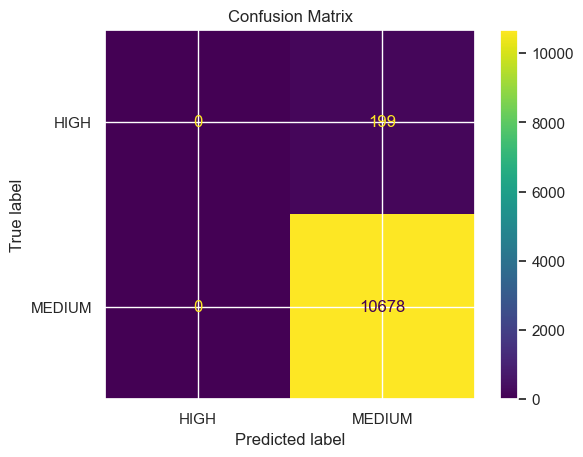

In [45]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

plt.figure()
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------

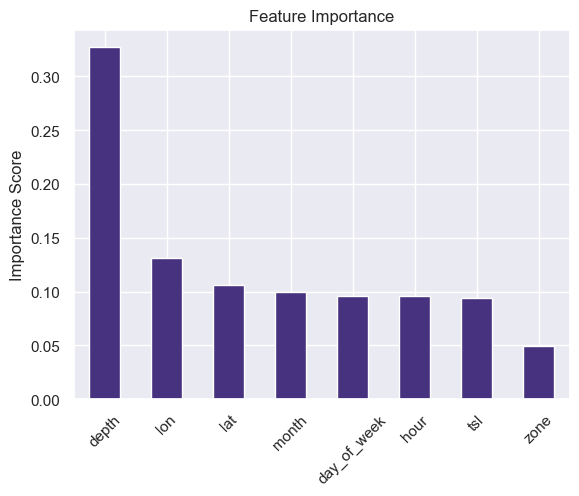

In [46]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()